In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn mlxtend

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report
from sklearn.ensemble import RandomForestClassifier

from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

import warnings
warnings.filterwarnings("ignore")

Step 2 — Load Dataset

In [3]:
df = pd.read_csv("/content/diabetic_data.csv")

print(df.shape)

print(df.head())

print(df.columns)

(101766, 50)
   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1  ...          No      No        

Step 3 — Data Preprocessing

In [5]:
df.drop_duplicates(inplace=True)

Replace missing values

In [6]:
df.replace("?", np.nan, inplace=True)

for column in df.columns:

    if df[column].dtype == "object":
        df[column].fillna(df[column].mode()[0], inplace=True)
    else:
        df[column].fillna(df[column].median(), inplace=True)

Remove useless columns

In [7]:
drop_cols = [
    "weight",
    "payer_code",
    "medical_specialty"
]

df.drop(columns=drop_cols, inplace=True)

Convert Age

In [8]:
print(df["age"].unique())

['[0-10)' '[10-20)' '[20-30)' '[30-40)' '[40-50)' '[50-60)' '[60-70)'
 '[70-80)' '[80-90)' '[90-100)']


Convert to midpoint values

In [9]:
age_map = {
"[0-10)":5,
"[10-20)":15,
"[20-30)":25,
"[30-40)":35,
"[40-50)":45,
"[50-60)":55,
"[60-70)":65,
"[70-80)":75,
"[80-90)":85,
"[90-100)":95
}

df["age"] = df["age"].map(age_map)

Encode Categorical Columns

In [10]:
encoder = LabelEncoder()

for col in df.columns:

    if df[col].dtype=="object":
        df[col]=encoder.fit_transform(df[col])

Step 4 — Exploratory Data Analysis

Age Distribution

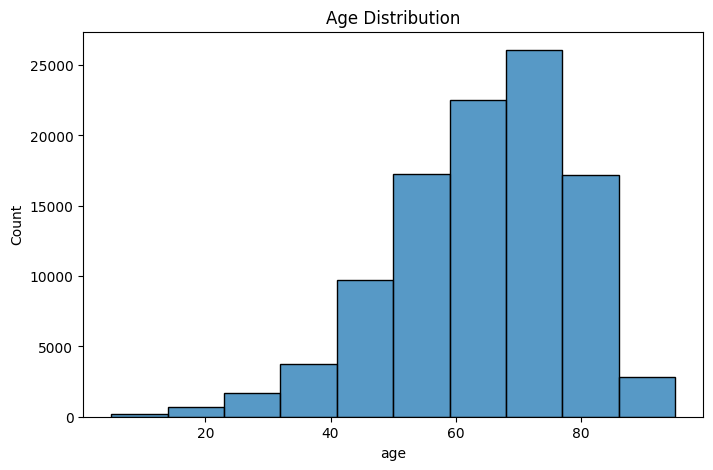

In [12]:
import os

plt.figure(figsize=(8,5))

sns.histplot(df["age"],bins=10)

plt.title("Age Distribution")

# Create the 'outputs' directory if it doesn't exist
os.makedirs('outputs', exist_ok=True)


plt.savefig("outputs/age_distribution.png")

plt.show()

Gender Distribution

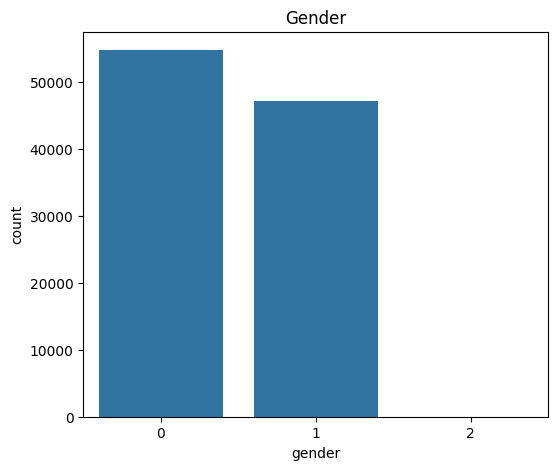

In [13]:
plt.figure(figsize=(6,5))

sns.countplot(x=df["gender"])

plt.title("Gender")

plt.savefig("outputs/gender.png")

plt.show()

Readmission Distribution

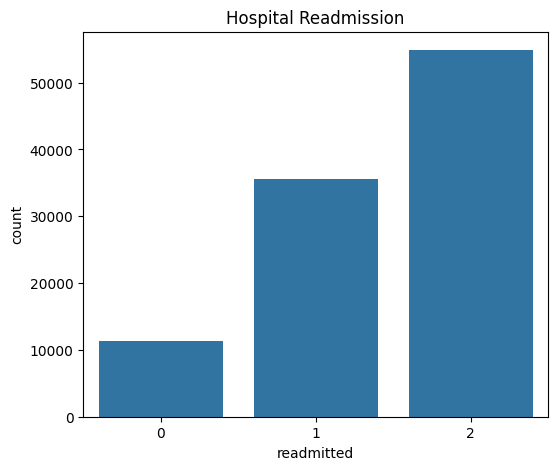

In [14]:
plt.figure(figsize=(6,5))

sns.countplot(x=df["readmitted"])

plt.title("Hospital Readmission")

plt.savefig("outputs/readmission.png")

plt.show()

Race Distribution

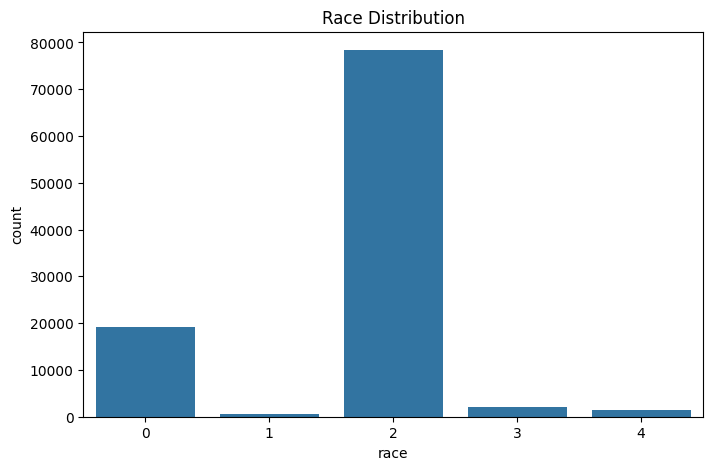

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(x=df["race"])

plt.title("Race Distribution")

plt.show()

Average Hospital Stay

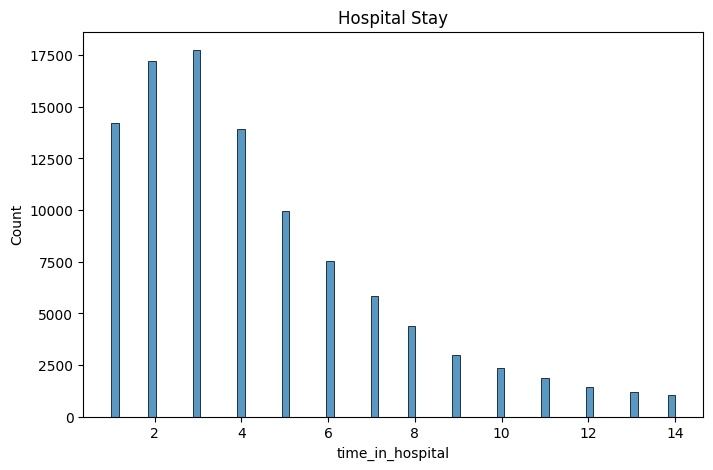

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(df["time_in_hospital"])

plt.title("Hospital Stay")

plt.show()

Admission Type

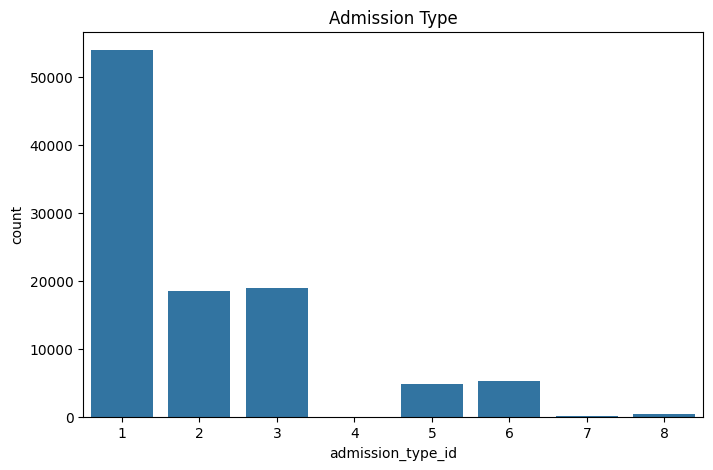

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(x=df["admission_type_id"])

plt.title("Admission Type")

plt.show()

Disease Pattern Analysis

Most Frequent Diagnosis

In [18]:
print(df["diag_1"].value_counts().head(15))

diag_1
276    6883
263    6581
540    4016
259    3614
325    3508
275    2766
329    2275
501    2151
475    2042
282    2028
534    2019
693    1967
143    1889
236    1688
121    1680
Name: count, dtype: int64


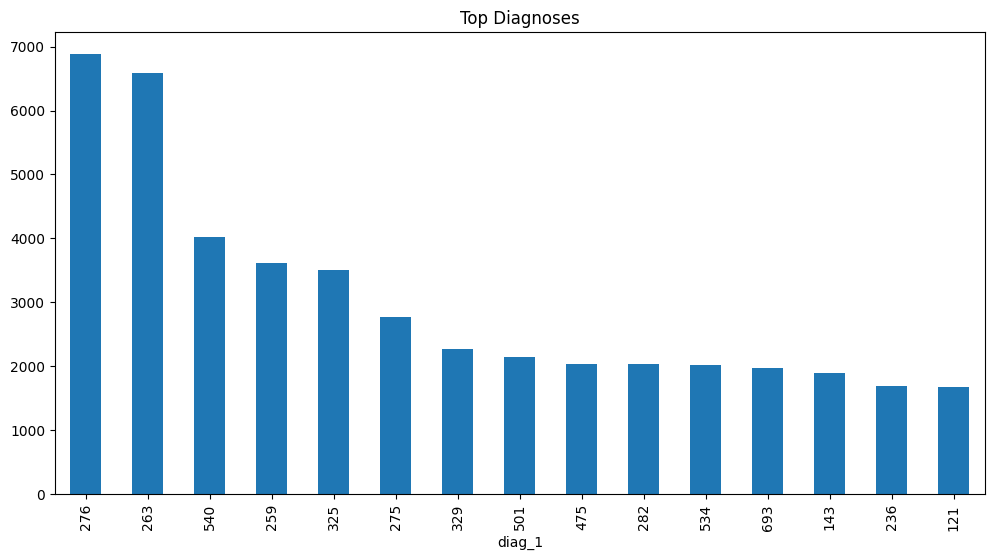

In [19]:
plt.figure(figsize=(12,6))

df["diag_1"].value_counts().head(15).plot(kind="bar")

plt.title("Top Diagnoses")

plt.show()

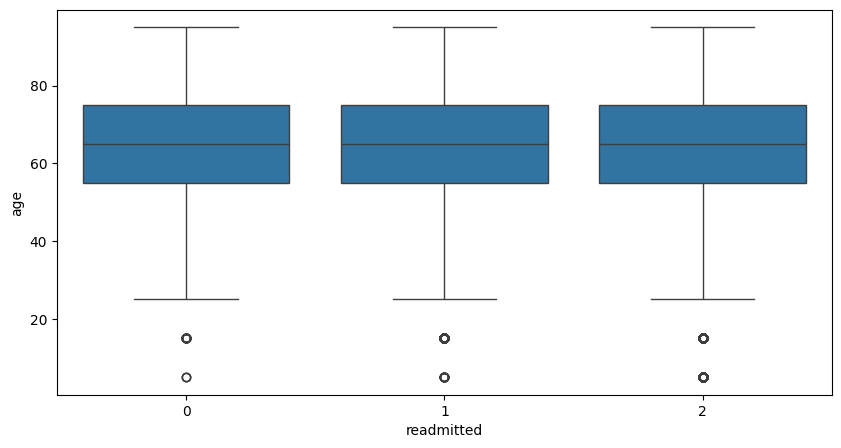

In [20]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df["readmitted"],
            y=df["age"])

plt.show()

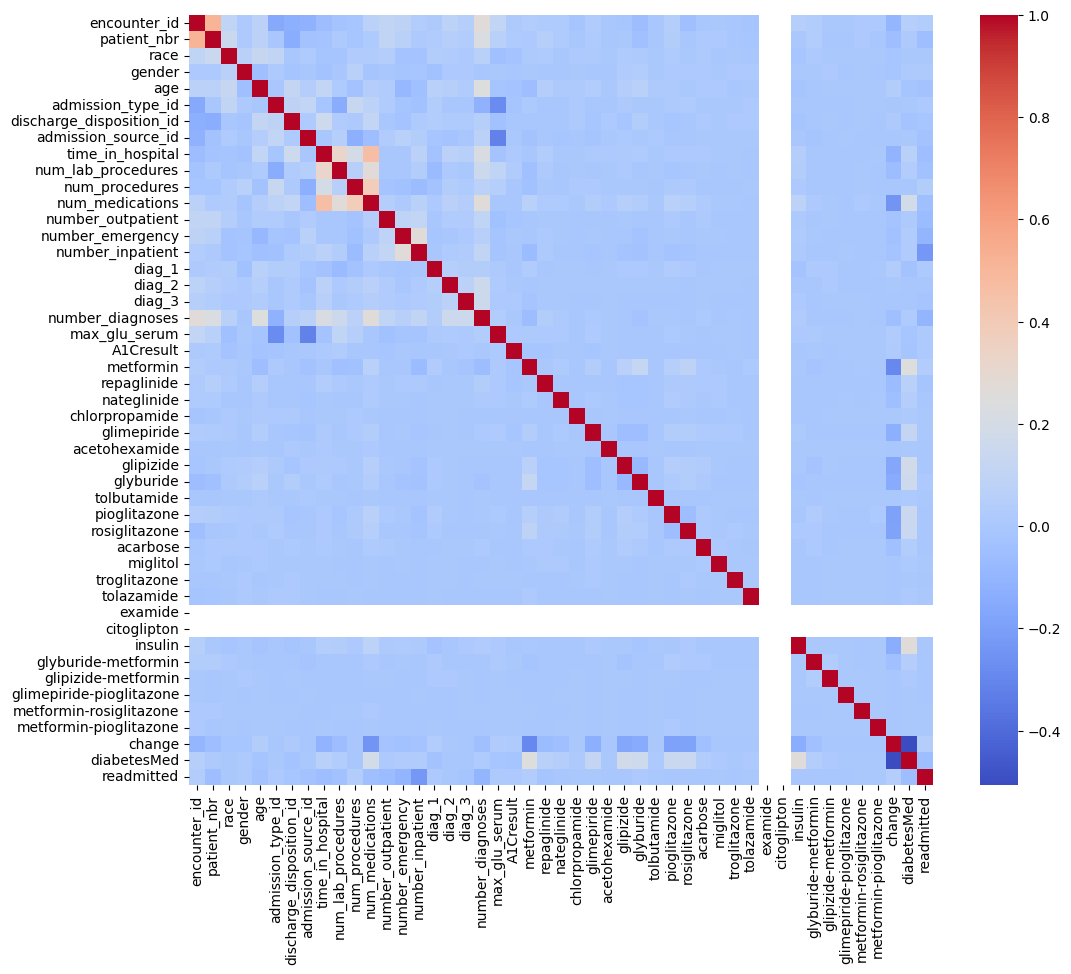

In [21]:
plt.figure(figsize=(12,10))

sns.heatmap(df.corr(),
            cmap="coolwarm")

plt.show()

Healthcare Trends
Average Hospital Stay

In [22]:
print(df["time_in_hospital"].describe())

count    101766.000000
mean          4.395987
std           2.985108
min           1.000000
25%           2.000000
50%           4.000000
75%           6.000000
max          14.000000
Name: time_in_hospital, dtype: float64


Average Lab Procedures

In [23]:
print(df["num_lab_procedures"].mean())

43.09564098028811


Average Medications

In [24]:
print(df["num_medications"].mean())

16.021844230882614


Emergency Visits

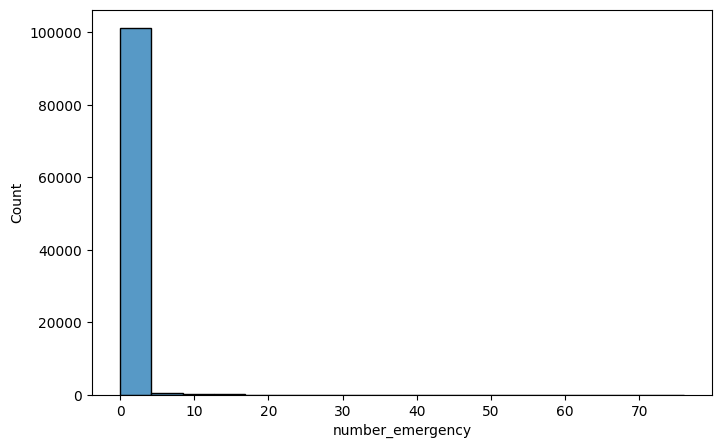

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(df["number_emergency"])

plt.show()

Inpatient Visits

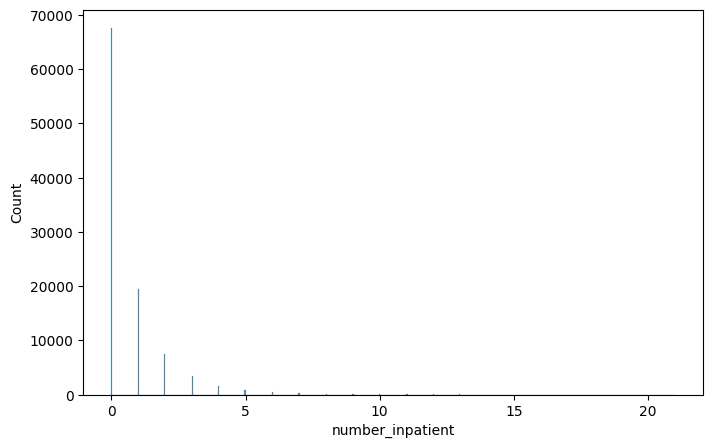

In [26]:
plt.figure(figsize=(8,5))

sns.histplot(df["number_inpatient"])

plt.show()

K-Means Clustering

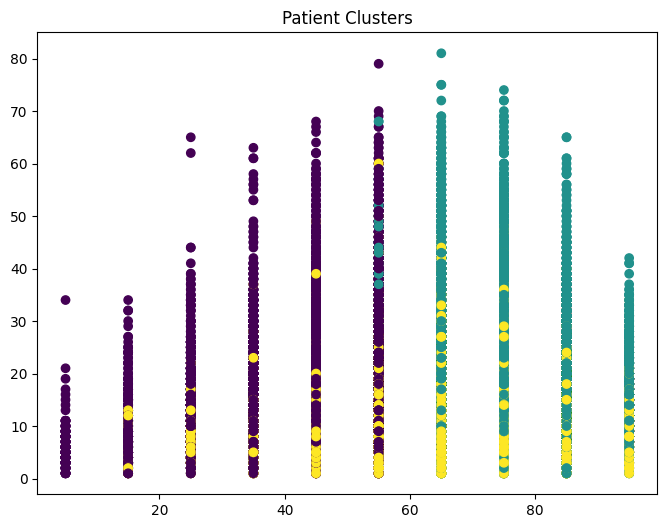

In [27]:
X = df[[
    "age",
    "time_in_hospital",
    "num_lab_procedures",
    "num_medications"
]]

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

df["Cluster"] = kmeans.fit_predict(X)

plt.figure(figsize=(8,6))

plt.scatter(df["age"],
            df["num_medications"],
            c=df["Cluster"])

plt.title("Patient Clusters")

plt.show()

Decision Tree Prediction

In [28]:
X = df.drop("readmitted",axis=1)

y = df["readmitted"]

X_train,X_test,y_train,y_test = train_test_split(
X,y,
test_size=0.2,
random_state=42)

tree = DecisionTreeClassifier()

tree.fit(X_train,y_train)

pred = tree.predict(X_test)

print("Accuracy")

print(accuracy_score(y_test,pred))

print(classification_report(y_test,pred))

Accuracy
0.4887000098260784
              precision    recall  f1-score   support

           0       0.16      0.17      0.16      2285
           1       0.42      0.42      0.42      7117
           2       0.61      0.60      0.60     10952

    accuracy                           0.49     20354
   macro avg       0.39      0.40      0.40     20354
weighted avg       0.49      0.49      0.49     20354



Random Forest

In [29]:
rf = RandomForestClassifier()

rf.fit(X_train,y_train)

pred = rf.predict(X_test)

print("Random Forest Accuracy")

print(accuracy_score(y_test,pred))

Random Forest Accuracy
0.6002751301955389


Association Rule Mining (Disease Patterns)

In [30]:
basket = pd.get_dummies(df["diag_1"].astype(str))

frequent = apriori(
    basket,
    min_support=0.01,
    use_colnames=True
)

rules = association_rules(
    frequent,
    metric="confidence",
    min_threshold=0.6
)

print(rules.head())

Empty DataFrame
Columns: [antecedents, consequents, antecedent support, consequent support, support, confidence, lift, representativity, leverage, conviction, zhangs_metric, jaccard, certainty, kulczynski]
Index: []


Medical Insights Report

In [31]:
report = open("report.txt","w")

report.write("HEALTHCARE DATA MINING REPORT\n")
report.write("="*40+"\n")

report.write(f"Total Patients : {len(df)}\n")

report.write(f"Average Age : {df['age'].mean():.2f}\n")

report.write(f"Average Stay : {df['time_in_hospital'].mean():.2f}\n")

report.write(f"Average Lab Tests : {df['num_lab_procedures'].mean():.2f}\n")

report.write(f"Average Medications : {df['num_medications'].mean():.2f}\n")

report.write("\nTop Diagnoses\n")

report.write(str(df["diag_1"].value_counts().head(10)))

report.close()

print("Medical report generated.")

Medical report generated.
